# Tarefa 4b — Redução de Dimensionalidade (PCA)
**Responsável:** Lucas

Aplicar PCA (Principal Component Analysis) ao dataset de preços de casas:
- Padronizar os dados antes de aplicar o PCA
- Determinar o número ideal de componentes principais
- Plotar a variância explicada acumulada (scree plot)
- Visualizar os dados em 2D após redução
- Interpretar quais variáveis mais contribuem para cada componente

## 1. Imports e Conexão com a API

In [1]:
import Connection as conn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Estilo dos gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Conexão com a API
my_conn = conn.get_conn("lucas_dev", "server@Database")
df = conn.puxar_df(my_conn)
print(f"Dataset carregado: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Dataset carregado: 1460 linhas x 19 colunas


,ms_subclass,ms_zoning,lot_area,street,neighborhood,overall_qual,overall_cond,year_built,year_remod_add,gr_liv_area,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,totrms_abvgrd,garage_cars,garage_area,sale_price,id
0,60,RL,8450,Pave,CollgCr,7,5,2003,2003,1710,2,1,3,1,8,2.0,548.0,208500,1
1,20,RL,9600,Pave,Veenker,6,8,1976,1976,1262,2,0,3,1,6,2.0,460.0,181500,2
2,60,RL,11250,Pave,CollgCr,7,5,2001,2002,1786,2,1,3,1,6,2.0,608.0,223500,3
3,70,RL,9550,Pave,Crawfor,7,5,1915,1970,1717,1,0,3,1,7,3.0,642.0,140000,4
4,60,RL,14260,Pave,NoRidge,8,5,2000,2000,2198,2,1,4,1,9,3.0,836.0,250000,5


## 2. Exploração inicial e seleção de variáveis numéricas

In [3]:
# Identificar colunas numéricas e categóricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Colunas numéricas ({len(numeric_cols)}): {numeric_cols}")
print(f"\nColunas categóricas ({len(cat_cols)}): {cat_cols}")

Colunas numéricas (16): ['ms_subclass', 'lot_area', 'overall_qual', 'overall_cond', 'year_built', 'year_remod_add', 'gr_liv_area', 'full_bath', 'half_bath', 'bedroom_abvgr', 'kitchen_abvgr', 'totrms_abvgrd', 'garage_cars', 'garage_area', 'sale_price', 'id']

Colunas categóricas (3): ['ms_zoning', 'street', 'neighborhood']


C:\Users\Matheus Games\AppData\Local\Temp\ipykernel_18692\2083269926.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [4]:
# Remover colunas que não são features (id, target)
cols_to_remove = ['id', 'sale_price']
feature_cols = [col for col in numeric_cols if col not in cols_to_remove]

print(f"Features selecionadas para PCA ({len(feature_cols)}):")
print(feature_cols)

# Preparar os dados removendo NaN
X = df[feature_cols].dropna()
print(f"\nAmostras após remoção de NaN: {X.shape[0]}")

Features selecionadas para PCA (14):
['ms_subclass', 'lot_area', 'overall_qual', 'overall_cond', 'year_built', 'year_remod_add', 'gr_liv_area', 'full_bath', 'half_bath', 'bedroom_abvgr', 'kitchen_abvgr', 'totrms_abvgrd', 'garage_cars', 'garage_area']

Amostras após remoção de NaN: 1460


## 3. Padronização dos dados
Antes de aplicar o PCA, é necessário padronizar os dados (média 0, desvio padrão 1) para que variáveis com escalas diferentes não dominem os componentes.

In [5]:
# Padronização com StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificar padronização
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
print("Estatísticas após padronização:")
print(f"  Média (deve ser ~0):  {X_scaled_df.mean().mean():.6f}")
print(f"  Desvio (deve ser ~1): {X_scaled_df.std().mean():.6f}")
X_scaled_df.describe().round(3)

Estatísticas após padronização:
  Média (deve ser ~0):  0.000000
  Desvio (deve ser ~1): 1.000343


,ms_subclass,lot_area,overall_qual,overall_cond,year_built,year_remod_add,gr_liv_area,full_bath,half_bath,bedroom_abvgr,kitchen_abvgr,totrms_abvgrd,garage_cars,garage_area
count,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000,1460.000
mean,-0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.873,-0.924,-3.688,-4.113,-3.288,-1.689,-2.249,-2.842,-0.762,-3.515,-4.751,-2.780,-2.365,-2.213
25%,-0.873,-0.297,-0.795,-0.517,-0.572,-0.866,-0.735,-1.026,-0.762,-1.062,-0.211,-0.934,-1.027,-0.648
50%,-0.163,-0.104,-0.072,-0.517,0.057,0.443,-0.098,0.790,-0.762,0.164,-0.211,-0.319,0.312,0.033
75%,0.310,0.109,0.651,0.382,0.952,0.927,0.497,0.790,1.228,0.164,-0.211,0.297,0.312,0.482
max,3.148,20.518,2.821,3.079,1.283,1.218,7.856,2.606,3.217,6.295,8.869,4.605,2.989,4.422


## 4. Determinação do número ideal de componentes principais
Aplicar PCA com todos os componentes e analisar a variância explicada acumulada para encontrar o ponto ideal (≥95% da variância).

In [6]:
# PCA com todos os componentes
pca_full = PCA()
pca_full.fit(X_scaled)

# Variância explicada
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Resumo dos primeiros componentes
print("Variância explicada por componente (top 15):")
for i in range(min(15, len(explained_var))):
    print(f"  PC{i+1}: {explained_var[i]*100:.2f}% (acumulada: {cumulative_var[i]*100:.2f}%)")

Variância explicada por componente (top 15):
  PC1: 33.64% (acumulada: 33.64%)
  PC2: 15.25% (acumulada: 48.89%)
  PC3: 9.87% (acumulada: 58.75%)
  PC4: 8.33% (acumulada: 67.08%)
  PC5: 6.92% (acumulada: 74.01%)
  PC6: 6.07% (acumulada: 80.07%)
  PC7: 5.69% (acumulada: 85.76%)
  PC8: 4.02% (acumulada: 89.78%)
  PC9: 3.06% (acumulada: 92.84%)
  PC10: 2.20% (acumulada: 95.04%)
  PC11: 2.08% (acumulada: 97.12%)
  PC12: 1.25% (acumulada: 98.37%)
  PC13: 0.94% (acumulada: 99.31%)
  PC14: 0.69% (acumulada: 100.00%)


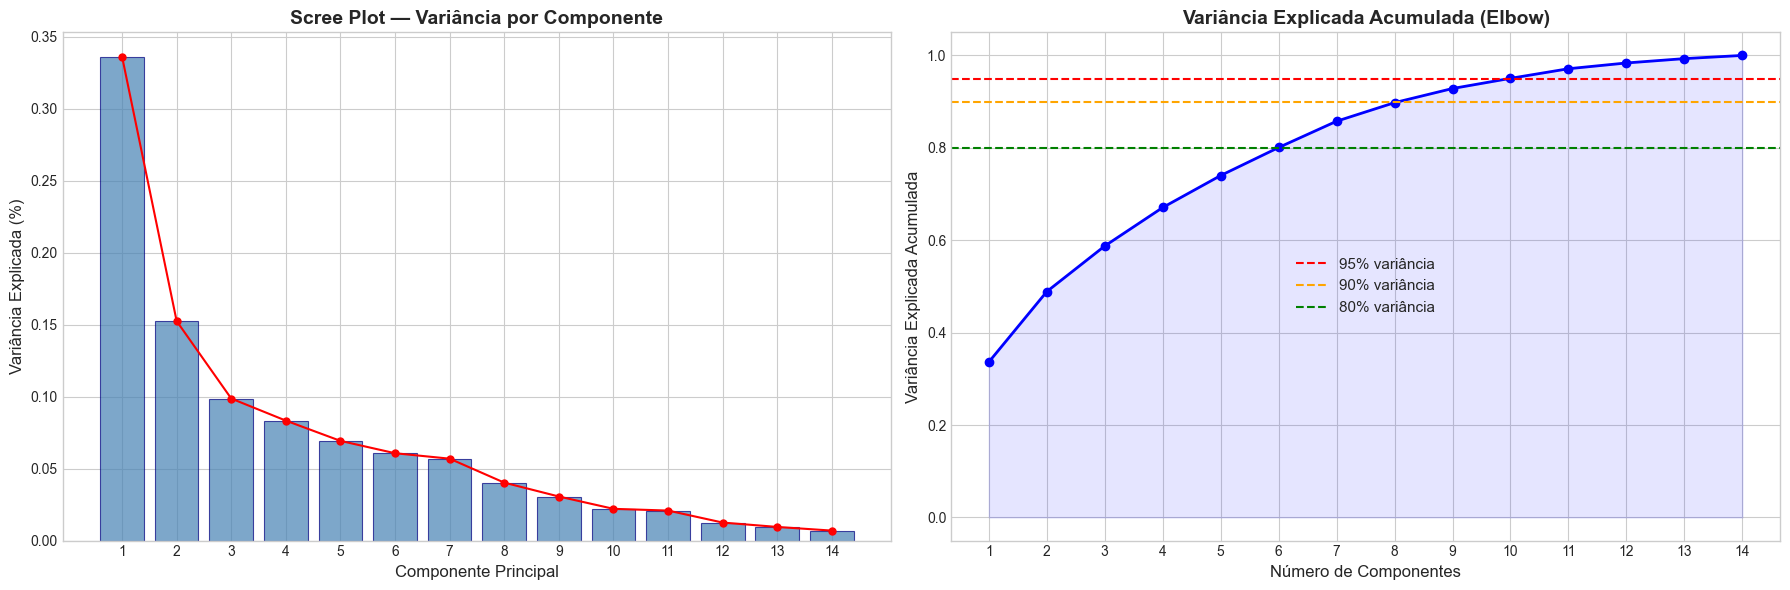


Número ideal de componentes:
  ≥80% variância: 6 componentes
  ≥90% variância: 9 componentes
  ≥95% variância: 10 componentes


In [7]:
# ============================================
# SCREE PLOT + VARIÂNCIA ACUMULADA
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Scree Plot ---
n_show = min(20, len(explained_var))  # Mostrar até 20 componentes
axes[0].bar(range(1, n_show + 1), explained_var[:n_show], 
            alpha=0.7, color='steelblue', edgecolor='navy', linewidth=0.8)
axes[0].plot(range(1, n_show + 1), explained_var[:n_show], 
             'ro-', markersize=5, linewidth=1.5)
axes[0].set_xlabel('Componente Principal', fontsize=12)
axes[0].set_ylabel('Variância Explicada (%)', fontsize=12)
axes[0].set_title('Scree Plot — Variância por Componente', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(1, n_show + 1))

# --- Variância Acumulada (Elbow Plot) ---
axes[1].plot(range(1, n_show + 1), cumulative_var[:n_show], 
             'bo-', linewidth=2, markersize=6)
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% variância')
axes[1].axhline(y=0.90, color='orange', linestyle='--', linewidth=1.5, label='90% variância')
axes[1].axhline(y=0.80, color='green', linestyle='--', linewidth=1.5, label='80% variância')
axes[1].fill_between(range(1, n_show + 1), cumulative_var[:n_show], alpha=0.1, color='blue')
axes[1].set_xlabel('Número de Componentes', fontsize=12)
axes[1].set_ylabel('Variância Explicada Acumulada', fontsize=12)
axes[1].set_title('Variância Explicada Acumulada (Elbow)', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(1, n_show + 1))
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Número ideal de componentes
n_ideal_95 = np.argmax(cumulative_var >= 0.95) + 1
n_ideal_90 = np.argmax(cumulative_var >= 0.90) + 1
n_ideal_80 = np.argmax(cumulative_var >= 0.80) + 1
print(f"\nNúmero ideal de componentes:")
print(f"  ≥80% variância: {n_ideal_80} componentes")
print(f"  ≥90% variância: {n_ideal_90} componentes")
print(f"  ≥95% variância: {n_ideal_95} componentes")

## 5. Visualização dos dados em 2D após redução (PCA)

In [8]:
# PCA com 2 componentes para visualização
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Variância explicada PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variância explicada PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"Variância total (2 comp): {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

Variância explicada PC1: 33.64%
Variância explicada PC2: 15.25%
Variância total (2 comp): 48.89%


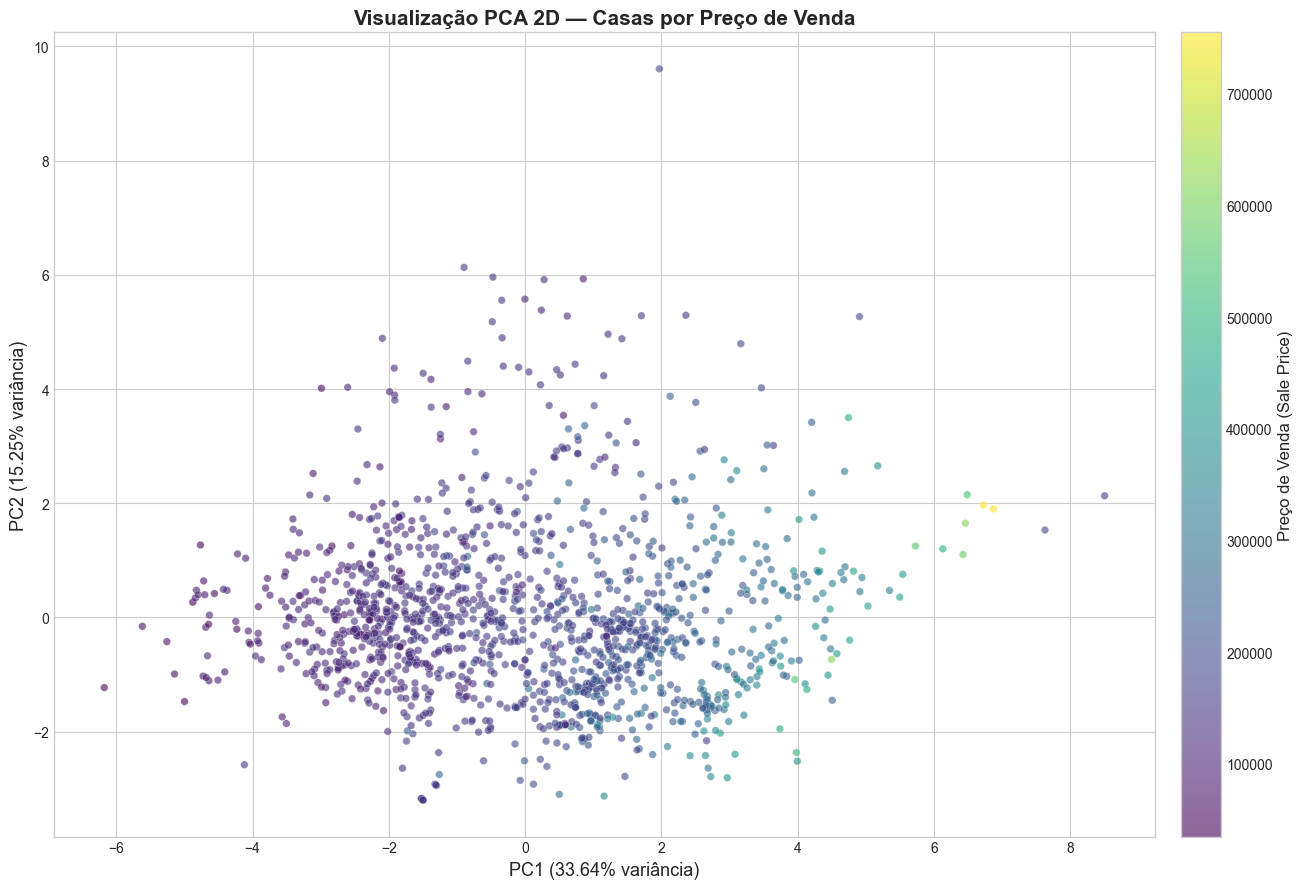

In [9]:
# ============================================
# SCATTER PLOT 2D — PCA colorido por Sale Price
# ============================================
fig, ax = plt.subplots(figsize=(14, 9))

scatter = ax.scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1],
    c=df.loc[X.index, 'sale_price'],
    cmap='viridis', alpha=0.6, edgecolors='w', linewidth=0.3, s=30
)

cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
cbar.set_label('Preço de Venda (Sale Price)', fontsize=12)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variância)', fontsize=13)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variância)', fontsize=13)
ax.set_title('Visualização PCA 2D — Casas por Preço de Venda', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Interpretação — Quais variáveis mais contribuem para cada componente
Analisar os **loadings** (pesos) de cada variável nos dois primeiros componentes principais.

In [10]:
# Loadings (contribuição de cada variável)
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

print("Loadings das variáveis nos 2 primeiros componentes:")
loadings.sort_values('PC1', ascending=False).round(4)

Loadings das variáveis nos 2 primeiros componentes:


,PC1,PC2
gr_liv_area,0.3730,0.2844
overall_qual,0.3693,-0.1639
garage_cars,0.3617,-0.1988
full_bath,0.3525,0.0896
garage_area,0.3419,-0.1971
totrms_abvgrd,0.3238,0.4118
year_built,0.2896,-0.3730
year_remod_add,0.2701,-0.2754
half_bath,0.1947,0.1009
bedroom_abvgr,0.1769,0.4905


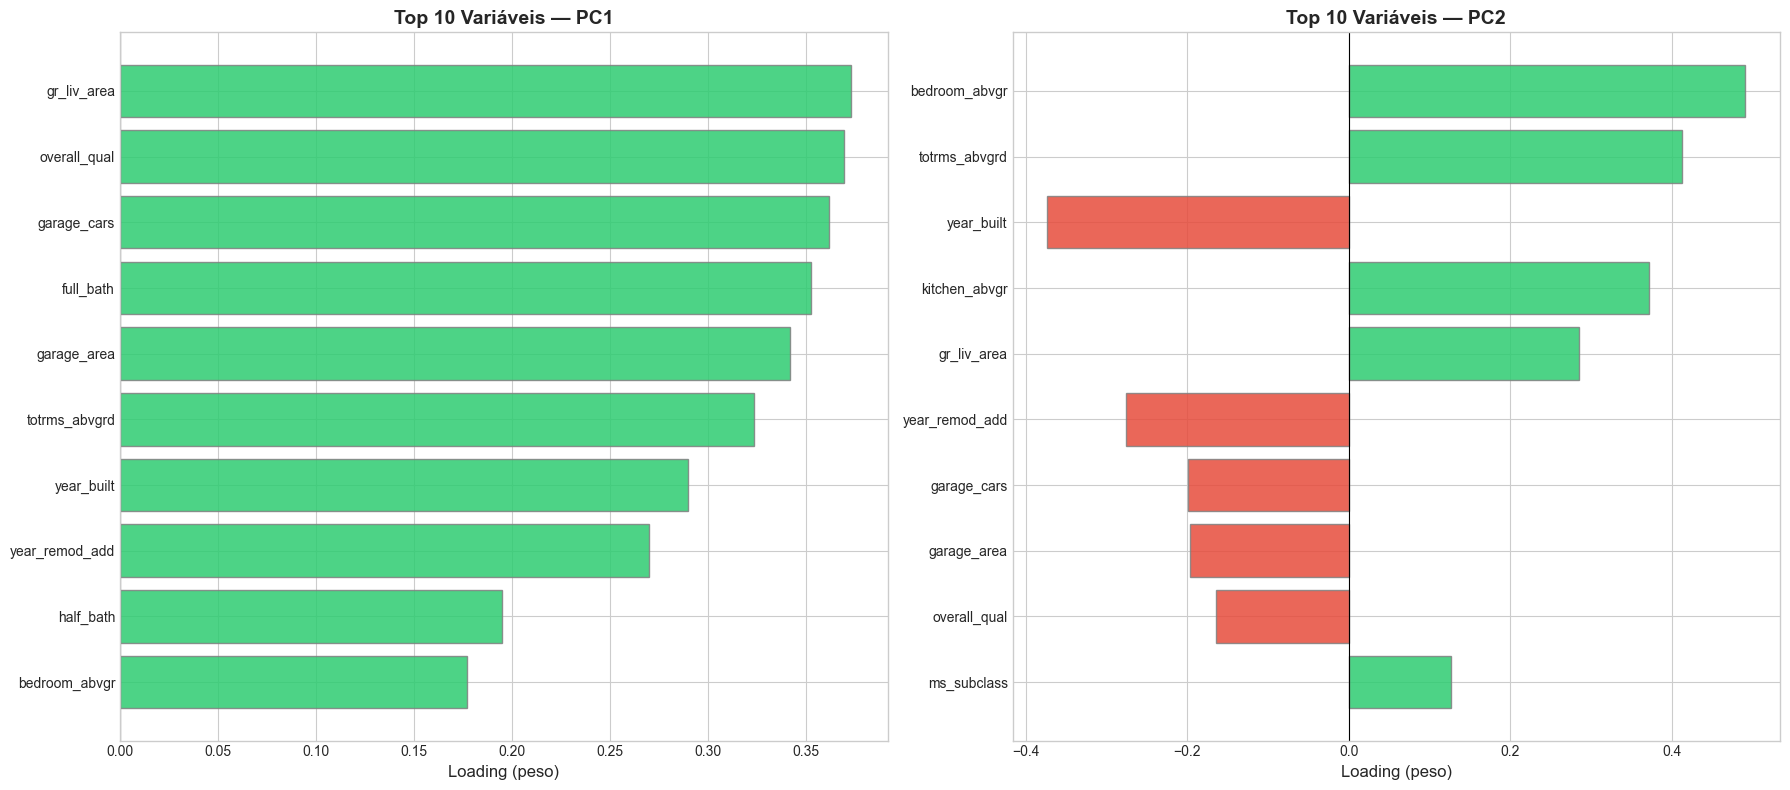

In [11]:
# ============================================
# TOP 10 VARIÁVEIS POR COMPONENTE (barras)
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- PC1 ---
top_pc1 = loadings['PC1'].abs().sort_values(ascending=True).tail(10)
top_pc1_vals = loadings.loc[top_pc1.index, 'PC1']
colors_pc1 = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_pc1_vals]
axes[0].barh(top_pc1.index, top_pc1_vals, color=colors_pc1, alpha=0.85, edgecolor='gray')
axes[0].set_title('Top 10 Variáveis — PC1', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loading (peso)', fontsize=12)
axes[0].axvline(x=0, color='black', linewidth=0.8)

# --- PC2 ---
top_pc2 = loadings['PC2'].abs().sort_values(ascending=True).tail(10)
top_pc2_vals = loadings.loc[top_pc2.index, 'PC2']
colors_pc2 = ['#2ecc71' if v > 0 else '#e74c3c' for v in top_pc2_vals]
axes[1].barh(top_pc2.index, top_pc2_vals, color=colors_pc2, alpha=0.85, edgecolor='gray')
axes[1].set_title('Top 10 Variáveis — PC2', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Loading (peso)', fontsize=12)
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

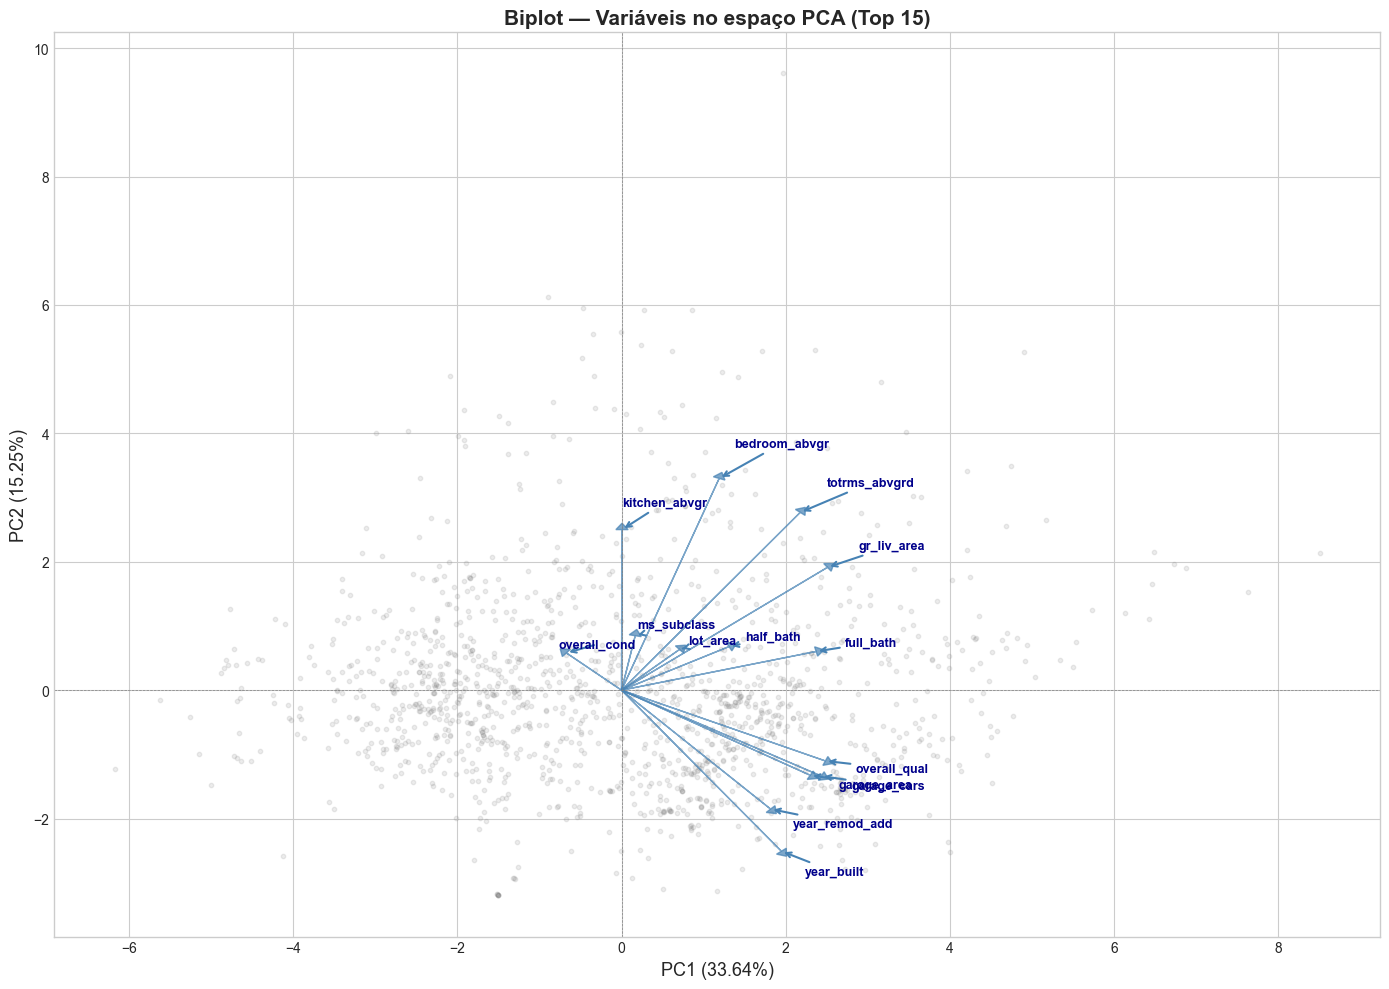

In [12]:
# ============================================
# BIPLOT — Vetores das variáveis no espaço PCA
# ============================================
fig, ax = plt.subplots(figsize=(14, 10))

# Pontos (amostras)
ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.15, s=10, color='gray')

# Vetores (variáveis) — top 15 por magnitude
top_vars = loadings.apply(lambda row: np.sqrt(row['PC1']**2 + row['PC2']**2), axis=1)
top_vars = top_vars.sort_values(ascending=False).head(15).index

scale_factor = max(X_pca_2d[:, 0].max(), X_pca_2d[:, 1].max()) * 0.7
for var in top_vars:
    ax.annotate(
        var,
        xy=(loadings.loc[var, 'PC1'] * scale_factor, 
            loadings.loc[var, 'PC2'] * scale_factor),
        fontsize=9, fontweight='bold', color='darkblue',
        arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5),
        xytext=(loadings.loc[var, 'PC1'] * scale_factor * 1.15,
                loadings.loc[var, 'PC2'] * scale_factor * 1.15)
    )
    ax.arrow(0, 0,
             loadings.loc[var, 'PC1'] * scale_factor,
             loadings.loc[var, 'PC2'] * scale_factor,
             head_width=0.15, head_length=0.1,
             fc='steelblue', ec='steelblue', alpha=0.7)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}%)', fontsize=13)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}%)', fontsize=13)
ax.set_title('Biplot — Variáveis no espaço PCA (Top 15)', fontsize=15, fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

## 7. Comparação com o endpoint da API (PCA)

In [13]:
# Resultado do PCA via API
pca_api = conn.get_pca(my_conn, n_components=2)
pca_api

{'usuario': 'matheus_root',
 'n_components': 2,
 'variancia_explicada': [0.402, 0.1687],
 'variancia_acumulada': [0.402, 0.5706],
 'loadings': {'PC1': {'lot_area': 0.1198,
   'overall_qual': 0.3695,
   'overall_cond': -0.1146,
   'year_built': 0.2752,
   'gr_liv_area': 0.3989,
   'full_bath': 0.3615,
   'half_bath': 0.2042,
   'bedroom_abvgr': 0.2075,
   'totrms_abvgrd': 0.3528,
   'garage_cars': 0.3704,
   'garage_area': 0.3522},
  'PC2': {'lot_area': 0.1174,
   'overall_qual': -0.1683,
   'overall_cond': 0.2596,
   'year_built': -0.4391,
   'gr_liv_area': 0.2822,
   'full_bath': 0.0348,
   'half_bath': 0.1237,
   'bedroom_abvgr': 0.5269,
   'totrms_abvgrd': 0.4055,
   'garage_cars': -0.2866,
   'garage_area': -0.2781}},
 'amostra_componentes': [{'PC1': 1.8432, 'PC2': -0.1767},
  {'PC1': -0.2912, 'PC2': 0.1799},
  {'PC1': 1.5809, 'PC2': -0.651},
  {'PC1': 0.4307, 'PC2': 0.0552},
  {'PC1': 3.9654, 'PC2': 0.2131},
  {'PC1': -0.9076, 'PC2': -1.9236},
  {'PC1': 1.6488, 'PC2': -0.9124},
  

In [14]:
# PCA com mais componentes via API
pca_api_5 = conn.get_pca(my_conn, n_components=5)
pca_api_5

{'usuario': 'matheus_root',
 'n_components': 5,
 'variancia_explicada': [0.402, 0.1687, 0.0975, 0.087, 0.0768],
 'variancia_acumulada': [0.402, 0.5706, 0.6681, 0.7551, 0.8319],
 'loadings': {'PC1': {'lot_area': 0.1198,
   'overall_qual': 0.3695,
   'overall_cond': -0.1146,
   'year_built': 0.2752,
   'gr_liv_area': 0.3989,
   'full_bath': 0.3615,
   'half_bath': 0.2042,
   'bedroom_abvgr': 0.2075,
   'totrms_abvgrd': 0.3528,
   'garage_cars': 0.3704,
   'garage_area': 0.3522},
  'PC2': {'lot_area': 0.1174,
   'overall_qual': -0.1683,
   'overall_cond': 0.2596,
   'year_built': -0.4391,
   'gr_liv_area': 0.2822,
   'full_bath': 0.0348,
   'half_bath': 0.1237,
   'bedroom_abvgr': 0.5269,
   'totrms_abvgrd': 0.4055,
   'garage_cars': -0.2866,
   'garage_area': -0.2781},
  'PC3': {'lot_area': 0.6205,
   'overall_qual': 0.0399,
   'overall_cond': 0.4867,
   'year_built': -0.2334,
   'gr_liv_area': 0.0178,
   'full_bath': -0.0911,
   'half_bath': -0.3861,
   'bedroom_abvgr': -0.15,
   'totrm

## 8. Heatmap de correlação dos componentes principais

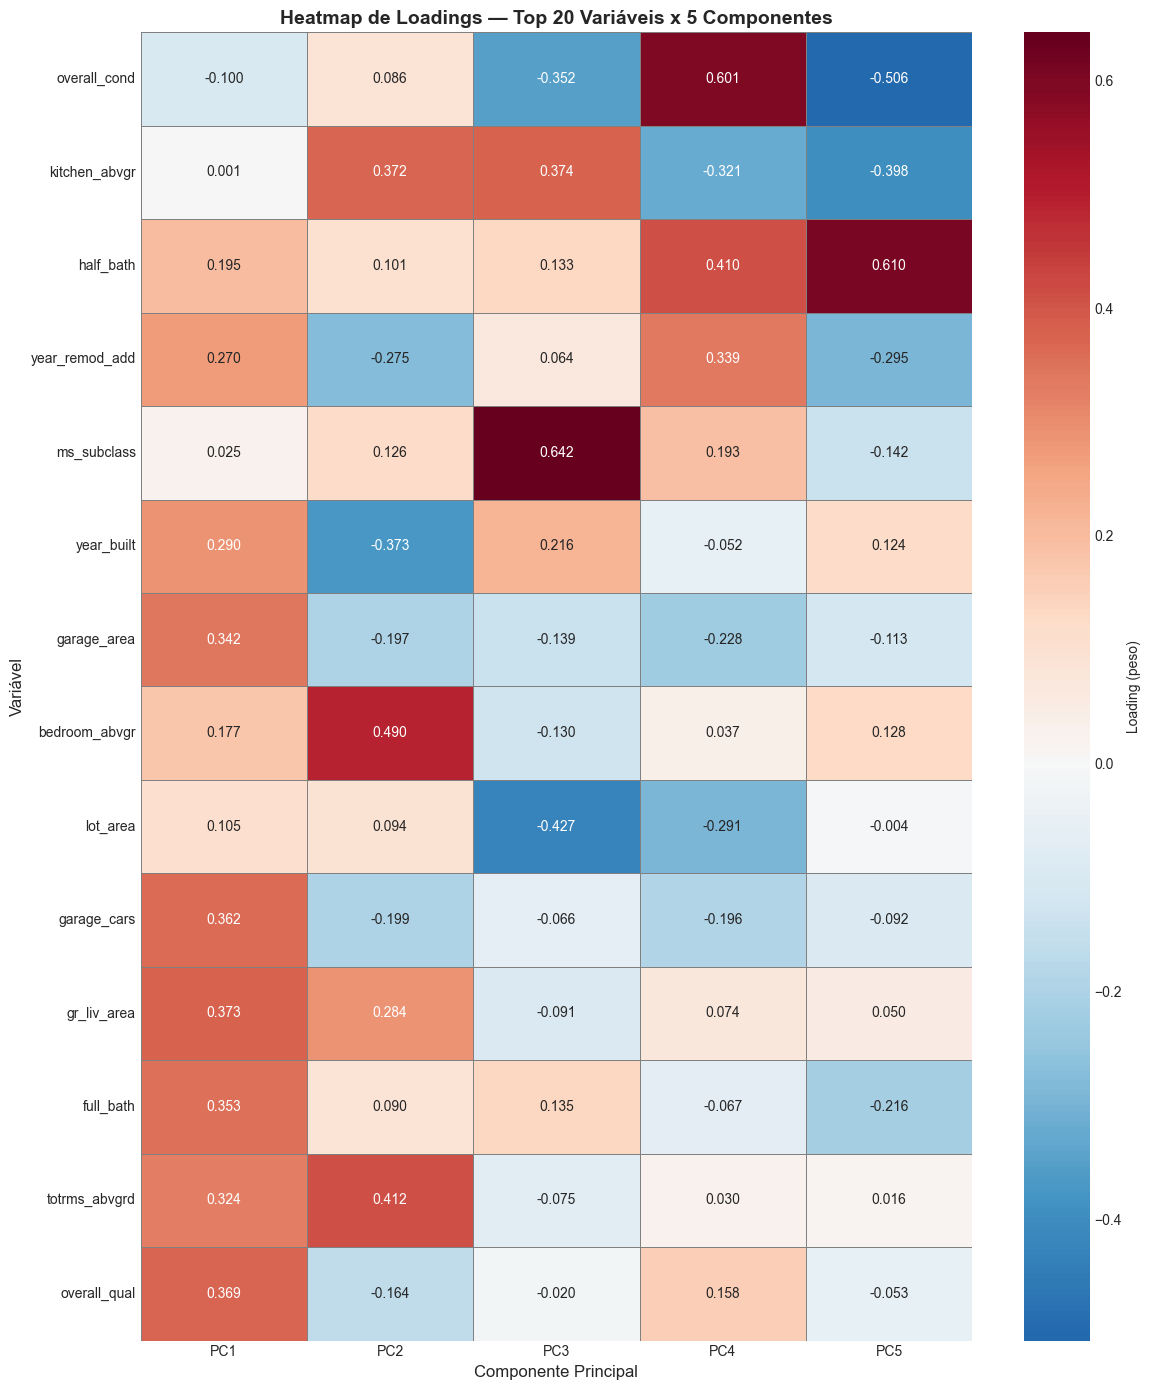

In [15]:
# ============================================
# HEATMAP DE LOADINGS (variáveis x componentes)
# ============================================
n_components_heatmap = min(5, len(explained_var))
pca_multi = PCA(n_components=n_components_heatmap)
pca_multi.fit(X_scaled)

loadings_multi = pd.DataFrame(
    pca_multi.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_heatmap)],
    index=feature_cols
)

# Selecionar top 20 variáveis por importância geral
importance = loadings_multi.abs().sum(axis=1).sort_values(ascending=False)
top_20 = importance.head(20).index

plt.figure(figsize=(12, 14))
sns.heatmap(
    loadings_multi.loc[top_20],
    annot=True, fmt='.3f', cmap='RdBu_r', center=0,
    linewidths=0.5, linecolor='gray',
    cbar_kws={'label': 'Loading (peso)'}
)
plt.title('Heatmap de Loadings — Top 20 Variáveis x 5 Componentes', 
          fontsize=14, fontweight='bold')
plt.xlabel('Componente Principal', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Resumo e Interpretação Final

In [16]:
print("=" * 65)
print("  RESUMO — ANÁLISE PCA (Redução de Dimensionalidade)")
print("=" * 65)

print(f"\n📊 Dataset: {X.shape[0]} amostras, {X.shape[1]} features numéricas")
print(f"\n📐 Padronização: StandardScaler (média=0, desvio=1)")

print(f"\n🔢 Número ideal de componentes:")
print(f"   ≥80% variância → {n_ideal_80} componentes")
print(f"   ≥90% variância → {n_ideal_90} componentes")
print(f"   ≥95% variância → {n_ideal_95} componentes")

print(f"\n📈 Variância explicada (2 componentes):")
print(f"   PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"   PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"   Total: {sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

print(f"\n🏆 Top 5 variáveis mais importantes para PC1:")
for var, val in loadings['PC1'].abs().sort_values(ascending=False).head(5).items():
    sinal = '+' if loadings.loc[var, 'PC1'] > 0 else '-'
    print(f"   {sinal} {var}: {loadings.loc[var, 'PC1']:.4f}")

print(f"\n🏆 Top 5 variáveis mais importantes para PC2:")
for var, val in loadings['PC2'].abs().sort_values(ascending=False).head(5).items():
    sinal = '+' if loadings.loc[var, 'PC2'] > 0 else '-'
    print(f"   {sinal} {var}: {loadings.loc[var, 'PC2']:.4f}")

print(f"\n" + "=" * 65)
print("  O PCA permite reduzir significativamente a dimensionalidade")
print("  do dataset mantendo a maior parte da informação relevante.")
print("  As variáveis com maiores loadings em PC1 e PC2 são as que")
print("  mais influenciam a separação dos dados no espaço reduzido.")
print("=" * 65)

  RESUMO — ANÁLISE PCA (Redução de Dimensionalidade)

📊 Dataset: 1460 amostras, 14 features numéricas

📐 Padronização: StandardScaler (média=0, desvio=1)

🔢 Número ideal de componentes:
   ≥80% variância → 6 componentes
   ≥90% variância → 9 componentes
   ≥95% variância → 10 componentes

📈 Variância explicada (2 componentes):
   PC1: 33.64%
   PC2: 15.25%
   Total: 48.89%

🏆 Top 5 variáveis mais importantes para PC1:
   + gr_liv_area: 0.3730
   + overall_qual: 0.3693
   + garage_cars: 0.3617
   + full_bath: 0.3525
   + garage_area: 0.3419

🏆 Top 5 variáveis mais importantes para PC2:
   + bedroom_abvgr: 0.4905
   + totrms_abvgrd: 0.4118
   - year_built: -0.3730
   + kitchen_abvgr: 0.3719
   + gr_liv_area: 0.2844

  O PCA permite reduzir significativamente a dimensionalidade
  do dataset mantendo a maior parte da informação relevante.
  As variáveis com maiores loadings em PC1 e PC2 são as que
  mais influenciam a separação dos dados no espaço reduzido.
